<a href="https://colab.research.google.com/github/alzaibaq/WaferMapWorkout/blob/master/KaggleCodeTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# loading libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
%matplotlib inline

import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# df=pd.read_pickle("/content/drive/MyDrive/LSWMD.pkl/LSWMD.pkl")
df=pd.read_pickle("/content/drive/MyDrive/Covid-19-Saftey/WaferMaps/LSWMD.pkl/LSWMD.pkl")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


In [ ]:
df.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [ ]:
df.tail()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
811452,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,23.0,[[Test]],[[Edge-Ring]]
811453,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,...",600.0,lot47542,24.0,[[Test]],[[Edge-Loc]]
811454,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,25.0,[[Test]],[[Edge-Ring]]
811455,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,...",600.0,lot47543,1.0,[],[]
811456,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47543,2.0,[],[]


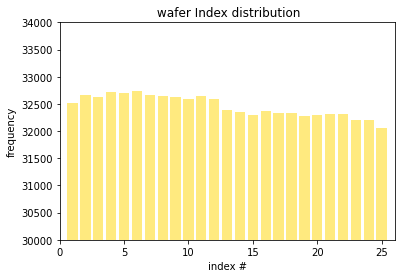

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


uni_Index=np.unique(df.waferIndex, return_counts=True)
plt.bar(uni_Index[0],uni_Index[1], color='gold', align='center', alpha=0.5)
plt.title(" wafer Index distribution")
plt.xlabel("index #")
plt.ylabel("frequency")
plt.xlim(0,26)
plt.ylim(30000,34000)
plt.show()

In [5]:
df = df.drop(['waferIndex'], axis = 1)

In [6]:
def find_dim(x):
    dim0=np.size(x,axis=0)
    dim1=np.size(x,axis=1)
    return dim0, dim1
df['waferMapDim']=df.waferMap.apply(find_dim)
df.sample(5)

,waferMap,dieSize,lotName,trianTestLabel,failureType,waferMapDim
725729,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",776.0,lot44060,[[Test]],[[none]],"(30, 34)"
189376,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2, 2,...",533.0,lot12050,[],[],"(26, 26)"
484469,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,...",846.0,lot30005,[],[],"(33, 33)"
199111,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3947.0,lot12723,[],[],"(66, 77)"
746730,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 2, 1,...",518.0,lot44913,[[Training]],[[none]],"(27, 25)"


In [ ]:
max(df.waferMapDim), min(df.waferMapDim)

((300, 202), (6, 21))

In [7]:
uni_waferDim=np.unique(df.waferMapDim, return_counts=True)
uni_waferDim[0].shape[0]

632

In [8]:
df['failureNum']=df.failureType
df['trainTestNum']=df.trianTestLabel
mapping_type={'Center':0,'Donut':1,'Edge-Loc':2,'Edge-Ring':3,'Loc':4,'Random':5,'Scratch':6,'Near-full':7,'none':8}
mapping_traintest={'Training':0,'Test':1}
df=df.replace({'failureNum':mapping_type, 'trainTestNum':mapping_traintest})

In [ ]:
df['failureNum']

0          8
1          8
2          8
3          8
4          8
          ..
811452     3
811453     2
811454     3
811455    []
811456    []
Name: failureNum, Length: 811457, dtype: object

In [9]:
tol_wafers = df.shape[0]
tol_wafers

811457

In [10]:
df_withlabel = df[(df['failureNum']>=0) & (df['failureNum']<=8)]
df_withlabel =df_withlabel.reset_index()
df_withpattern = df[(df['failureNum']>=0) & (df['failureNum']<=7)]
df_withpattern = df_withpattern.reset_index()
df_nonpattern = df[(df['failureNum']==8)]
#df_withlabel.shape[0]
df_withpattern.shape[0], df_nonpattern.shape[0]

(25519, 147431)

In [11]:
import pandas as pd
import numpy as np
np.random.seed(10)

df_balanced = df_withpattern.copy()

l = list(mapping_type)
for i in range(8):
    n = df_withpattern[df_withpattern['failureNum']==i].shape[0]
    print(f'\n{l[i]} before: {n}')
    if n <= 800:
        print("not dropping any")
        continue
    remove_n = n - 800
    print(f'dropping {remove_n}')
    drop_indices = np.random.choice(df_balanced[df_balanced['failureNum']==i].index, remove_n, replace=False)
    df_balanced = df_balanced.drop(drop_indices)

print("\nResults after balancing the dataset")
for i in range(8):
    n = df_balanced[df_balanced['failureNum']==i].shape[0]
    print(l[i], n)


Center before: 4294
dropping 3494

Donut before: 555
not dropping any

Edge-Loc before: 5189
dropping 4389

Edge-Ring before: 9680
dropping 8880

Loc before: 3593
dropping 2793

Random before: 866
dropping 66

Scratch before: 1193
dropping 393

Near-full before: 149
not dropping any

Results after balancing the dataset
Center 800
Donut 555
Edge-Loc 800
Edge-Ring 800
Loc 800
Random 800
Scratch 800
Near-full 149


In [12]:
df_balanced = df_balanced.reset_index(drop=True)
#This is where we perform rotaion
# print(df_balanced.columns)
# print(df_balanced[['waferMap']])
# o = df_balanced.loc[[2]]["failureType"]
# print(o, type(o))
# print(o.loc[[0]])

# print(df_balanced.loc[[1]])#['failureType'])


#df_balanced = df_balanced.reset_index(drop=True)

In [52]:
# import cv2

# print(new_df_rotated.head())#.loc[[1]]["failureType"])
# print(answer[3])


# print(df_balanced_bkp.columns)
# print(df_balanced.loc[[0]]["waferMap"])
# o = df_balanced.loc[[0]]["waferMap"].tolist()
# print(o, type(o))

# print(df_balanced_bkp.loc[[0]]["waferMap"])
# o = df_balanced_bkp.loc[[0]]["waferMap"].tolist()
# print("O:", o, type(o))

# a = np.ndarray([1,2])
# np.rot90(a)


# print(o, type(o))
# o2 = np.rot90(o[0])
# o3 = o2.astype(list)
# print("O2:", o2, type(o2))
# print(pd.core.series.Series(o2[0]))
# print(list([o2]))
# o3 = list([o2])


# print("O:", o[0][i])
# print("O3:", o3[0][i])

# df_balanced_bkp = df_balanced.copy()
# wm = df_balanced.loc[[i]]["waferMap"].tolist()
# wm = pd.core.series.Series(list([np.rot90(wm[0], 2)]))

# print(wm)

# del answer, new_df_rotated

df_balanced = df_balanced_bkp.copy()

In [ ]:
# just a backup:
# answer = []
# for i in range (len(df_balanced)):
#   print(i)
#   answer.append({'waferMap' : df_balanced[i:i+1]['waferMap'].tolist()[0][0][0], 'dieSize' : df_balanced[i:i+1]['dieSize'].tolist()[0], 'lotName' : df_balanced[i:i+1]['lotName'].tolist()[0], 'trianTestLabel' : df_balanced[i:i+1]['trianTestLabel'].tolist()[0][0][0], 'failureType': df_balanced[i:i+1]['failureType'].tolist()[0][0][0], 'waferMapDim' : df_balanced[i:i+1]['waferMapDim'].tolist()[0], 'failureNum' : df_balanced[i:i+1]['failureNum'].tolist()[0], 'trainTestNum' : df_balanced[i:i+1]['trainTestNum'].tolist()[0]})
#   temp = df_balanced[i: i+1]['waferMap'].tolist()[0]
#   for j in range (3):
#     np.rot90(temp)
#     #answer.append([temp, df_balanced[i:i+1]['dieSize'].tolist()[0], df_balanced[i:i+1]['lotName'].tolist()[0],df_balanced[i:i+1]['trianTestLabel'].tolist()[0][0], df_balanced[i:i+1]['failureType'].tolist()[0][0], df_balanced[i:i+1]['waferMapDim'].tolist()[0],df_balanced[i:i+1]['failureNum'].tolist()[0], df_balanced[i:i+1]['trainTestNum'].tolist()[0]])
#     answer.append({'waferMap' : temp[0], 'dieSize' : df_balanced[i:i+1]['dieSize'].tolist()[0], 'lotName' : df_balanced[i:i+1]['lotName'].tolist()[0], 'trianTestLabel' : df_balanced[i:i+1]['trianTestLabel'].tolist()[0][0][0], 'failureType': df_balanced[i:i+1]['failureType'].tolist()[0][0][0], 'waferMapDim' : df_balanced[i:i+1]['waferMapDim'].tolist()[0], 'failureNum' : df_balanced[i:i+1]['failureNum'].tolist()[0], 'trainTestNum' : df_balanced[i:i+1]['trainTestNum'].tolist()[0]})


In [50]:
df_balanced['waferMap'][0].shape

(53, 58)

In [53]:
#This is where we perform rotaion
#print(df_balanced[['waferMap', 'dieSize', 'lotName', 'trianTestLabel', 'failureType', 'waferMapDim', 'failureNum', 'trainTestNum']])
#print(df_balanced[0:1])

columns = ['waferMap', 'dieSize', 'lotName', 'trianTestLabel', 'failureType', 'waferMapDim', 'failureNum', 'trainTestNum']
new_df_rotated = pd.DataFrame(columns = columns)
# '''
answer = []
for i in range(len(df_balanced)):
    
    print(i)
    answer.append({'waferMap' : df_balanced['waferMap'][i], 'dieSize' : df_balanced.loc[[i]]['dieSize'].to_list()[0], 'lotName' : df_balanced.loc[[i]]['lotName'].to_list()[0], 'trianTestLabel' : df_balanced.loc[[i]]['trianTestLabel'].to_list()[0], 'failureType': df_balanced.loc[[i]]['failureType'].to_list()[0], 'waferMapDim' : df_balanced.loc[[i]]['waferMapDim'].to_list()[0], 'failureNum' : df_balanced.loc[[i]]['failureNum'].to_list()[0], 'trainTestNum' : df_balanced.loc[[i]]['trainTestNum'].to_list()[0]})
    #temp = df_balanced.loc[[i]]['waferMap'].tolist()[0]
    for j in range(1, 4):
        #wm = df_balanced.loc[[i]]["waferMap"].tolist()
        wm = df_balanced['waferMap'][i]
        wm = np.rot90(wm, k=j)

        #wmd = df_balanced.loc[[i]]["waferMapDim"].to_list()[0]
        #if i == 1 or i == 3:
            #wmd = (wmd[1], wmd[0])
        wmd = wm[0].shape
        wmd = tuple(pd.core.series.Series(wmd))
        # temp = np.rot90(temp)
        #answer.append([temp, df_balanced.loc[[i]]['dieSize'].tolist()[0], df_balanced.loc[[i]]['lotName'].tolist()[0],df_balanced.loc[[i]]['trianTestLabel'].tolist()[0][0], df_balanced.loc[[i]]['failureType'].tolist()[0][0], df_balanced.loc[[i]]['waferMapDim'].tolist()[0],df_balanced.loc[[i]]['failureNum'].tolist()[0], df_balanced.loc[[i]]['trainTestNum'].tolist()[0]])
        answer.append({'waferMap' : wm, 'dieSize' : df_balanced.loc[[i]]['dieSize'].to_list()[0], 'lotName' : df_balanced.loc[[i]]['lotName'].to_list()[0], 'trianTestLabel' : df_balanced.loc[[i]]['trianTestLabel'].to_list()[0], 'failureType': df_balanced.loc[[i]]['failureType'].to_list()[0], 'waferMapDim' : wmd, 'failureNum' : df_balanced.loc[[i]]['failureNum'].to_list()[0], 'trainTestNum' : df_balanced.loc[[i]]['trainTestNum'].to_list()[0]})
# '''


# df_balanced.loc[[i]]["failureType"]
#print(df_balanced[0:1]['failureType'].tolist()[0][0][0])
#print(df_balanced[0:1]['failureNum'].tolist()[0])
#columns = ['waferMap', 'dieSize', 'lotName', 'trianTestLabel', 'failureType', 'waferMapDim', 'failureNum', 'trainTestNum']
new_df_rotated = pd.DataFrame(answer)
print(new_df_rotated.loc[[1]]["failureType"], new_df_rotated.loc[[1]]["waferMap"])
#testdf = pd.DataFrame(test)


Streaming output truncated to the last 5000 lines.
507
508
509
510
511
512
513
514
515
516
517
518
519
520
521
522
523
524
525
526
527
528
529
530
531
532
533
534
535
536
537
538
539
540
541
542
543
544
545
546
547
548
549
550
551
552
553
554
555
556
557
558
559
560
561
562
563
564
565
566
567
568
569
570
571
572
573
574
575
576
577
578
579
580
581
582
583
584
585
586
587
588
589
590
591
592
593
594
595
596
597
598
599
600
601
602
603
604
605
606
607
608
609
610
611
612
613
614
615
616
617
618
619
620
621
622
623
624
625
626
627
628
629
630
631
632
633
634
635
636
637
638
639
640
641
642
643
644
645
646
647
648
649
650
651
652
653
654
655
656
657
658
659
660
661
662
663
664
665
666
667
668
669
670
671
672
673
674
675
676
677
678
679
680
681
682
683
684
685
686
687
688
689
690
691
692
693
694
695
696
697
698
699
700
701
702
703
704
705
706
707
708
709
710
711
712
713
714
715
716
717
718
719
720
721
722
723
724
725
726
727
728
729
730
731
732
733
734
735
736
737
738
739
740
741
742
743
7

In [59]:
# df_balanced_bkp = df_balanced.copy()
df_balanced = new_df_rotated

KeyError: ignored

In [58]:
a = df_balanced_bkp.loc[0]
print(a, type(a), '\n-----')
b = df_balanced.loc[0]
print(b, type(b))


index                                                            37
waferMap          [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
dieSize                                                        2460
lotName                                                        lot2
trianTestLabel                                         [[Training]]
failureType                                            [[Edge-Loc]]
waferMapDim                                                (53, 58)
failureNum                                                        2
trainTestNum                                                      0
Name: 0, dtype: object <class 'pandas.core.series.Series'> 
-----
waferMap          [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
dieSize                                                        2460
lotName                                                        lot2
trianTestLabel                                         [[Training]]
failureType                                       

In [60]:
print(df_balanced.columns)
for i in range(10):
    o = df_balanced.loc[[i]]["waferMap"].to_list()[0]
    # wmd = (o[1], o[0])
    # print(i, o)#, type(o))
    print(o)
    #print(i, wmd, type(wmd))
    # print(tuple(pd.core.series.Series(wmd)))

Index(['waferMap', 'dieSize', 'lotName', 'trianTestLabel', 'failureType',
       'waferMapDim', 'failureNum', 'trainTestNum'],
      dtype='object')
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ...

In [61]:
for i in range(30, 90):
    o = df_balanced_bkp.loc[[i]]["failureType"]
    print(o, type(o))

30    [[Loc]]
Name: failureType, dtype: object <class 'pandas.core.series.Series'>
31    [[Scratch]]
Name: failureType, dtype: object <class 'pandas.core.series.Series'>
32    [[Edge-Loc]]
Name: failureType, dtype: object <class 'pandas.core.series.Series'>
33    [[Random]]
Name: failureType, dtype: object <class 'pandas.core.series.Series'>
34    [[Near-full]]
Name: failureType, dtype: object <class 'pandas.core.series.Series'>
35    [[Random]]
Name: failureType, dtype: object <class 'pandas.core.series.Series'>
36    [[Random]]
Name: failureType, dtype: object <class 'pandas.core.series.Series'>
37    [[Random]]
Name: failureType, dtype: object <class 'pandas.core.series.Series'>
38    [[Random]]
Name: failureType, dtype: object <class 'pandas.core.series.Series'>
39    [[Random]]
Name: failureType, dtype: object <class 'pandas.core.series.Series'>
40    [[Scratch]]
Name: failureType, dtype: object <class 'pandas.core.series.Series'>
41    [[Near-full]]
Name: failureType, dtype: obje

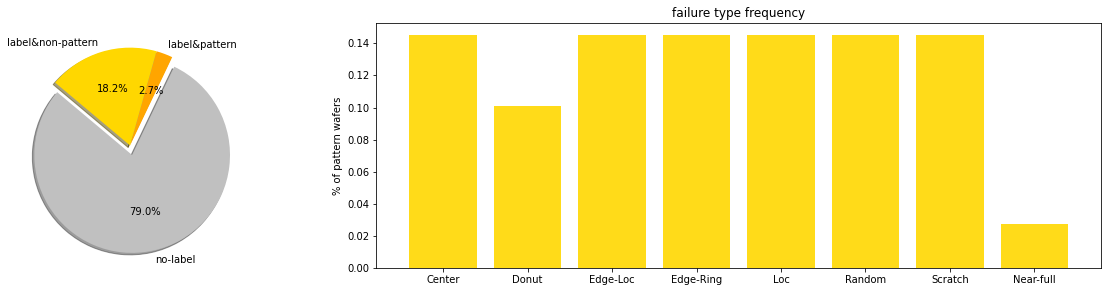

In [62]:
import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib import gridspec
fig = plt.figure(figsize=(20, 4.5)) 
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2.5]) 
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

no_wafers=[tol_wafers-df_withlabel.shape[0], df_balanced.shape[0], df_nonpattern.shape[0]]

colors = ['silver', 'orange', 'gold']
explode = (0.1, 0, 0)  # explode 1st slice
labels = ['no-label','label&pattern','label&non-pattern']
ax1.pie(no_wafers, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)

uni_pattern=np.unique(df_balanced.failureNum, return_counts=True)
labels2 = ['','Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']
ax2.bar(uni_pattern[0],uni_pattern[1]/df_balanced.shape[0], color='gold', align='center', alpha=0.9)
ax2.set_title("failure type frequency")
ax2.set_ylabel("% of pattern wafers")
ax2.set_xticklabels(labels2)

plt.show()

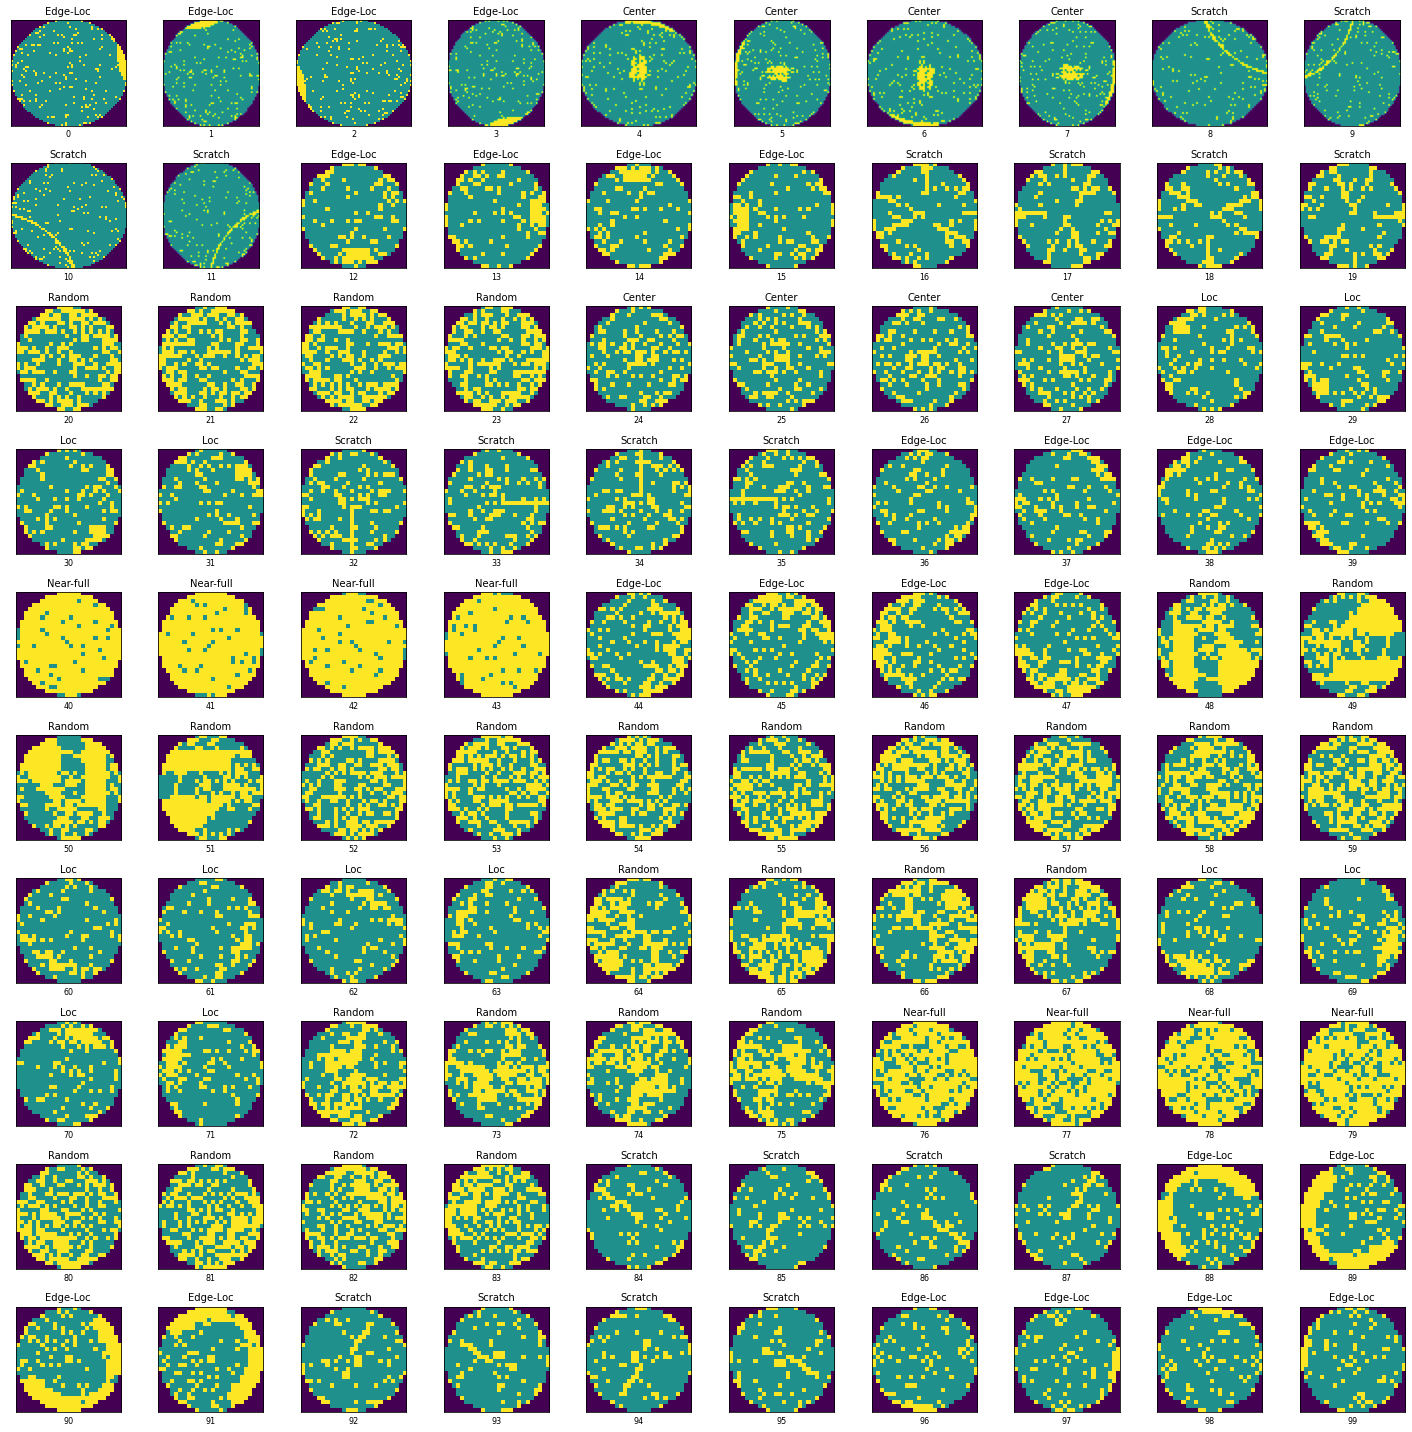

In [63]:
fig, ax = plt.subplots(nrows = 10, ncols = 10, figsize=(20, 20))
ax = ax.ravel(order='C')
for i in range(100):
    img = df_balanced.waferMap[i]
    ax[i].imshow(img)
    ax[i].set_title(df_balanced.failureType[i][0][0], fontsize=10)
    ax[i].set_xlabel(df_balanced.index[i], fontsize=8)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.tight_layout()
plt.show() 

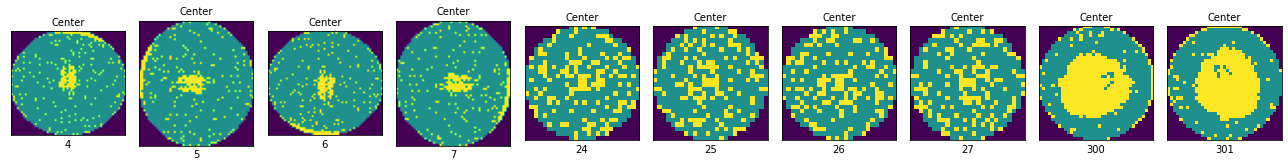

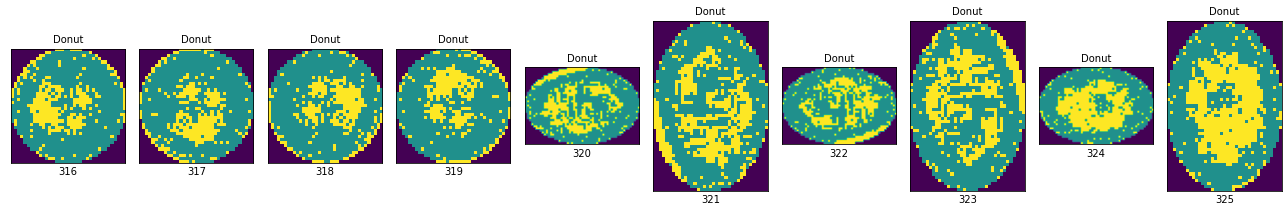

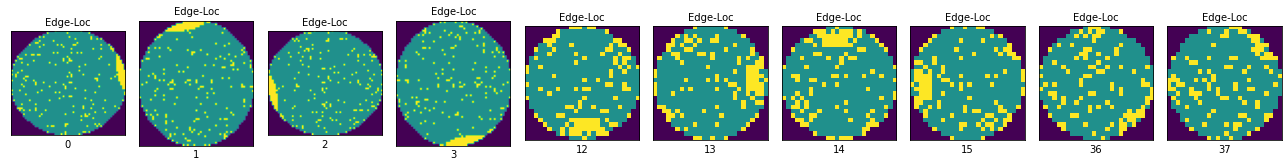

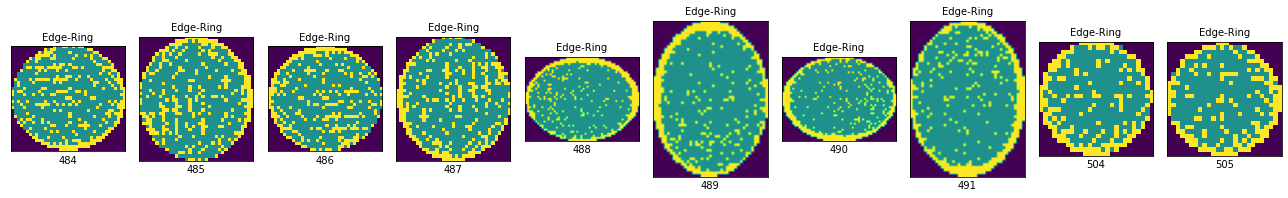

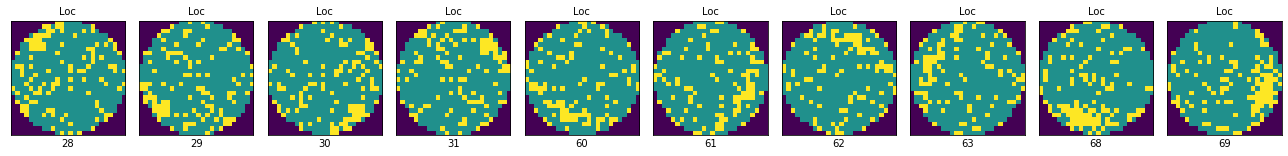

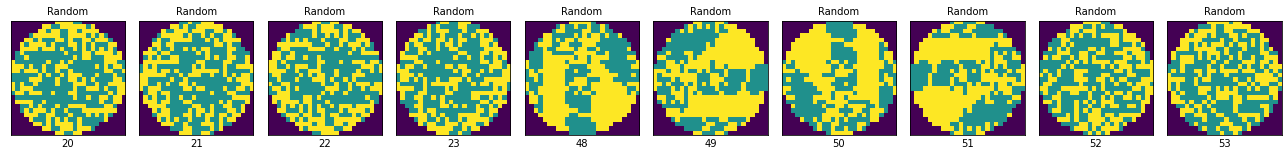

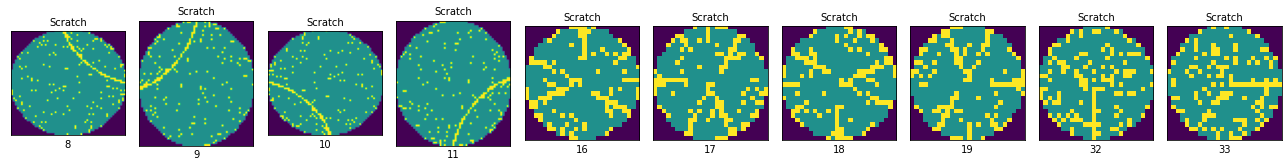

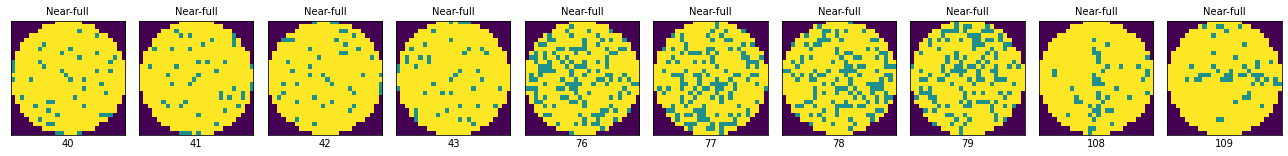

In [64]:
x = [0,1,2,3,4,5,6,7]
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

for k in x:
    fig, ax = plt.subplots(nrows = 1, ncols = 10, figsize=(18, 12))
    ax = ax.ravel(order='C')
    for j in [k]:
        img = df_balanced.waferMap[df_balanced.failureType==labels2[j]]
        for i in range(10):
            ax[i].imshow(img[img.index[i]])
            ax[i].set_title(df_balanced.failureType[img.index[i]][0][0], fontsize=10)
            ax[i].set_xlabel(df_balanced.index[img.index[i]], fontsize=10)
            ax[i].set_xticks([])
            ax[i].set_yticks([])
    plt.tight_layout()
    plt.show() 

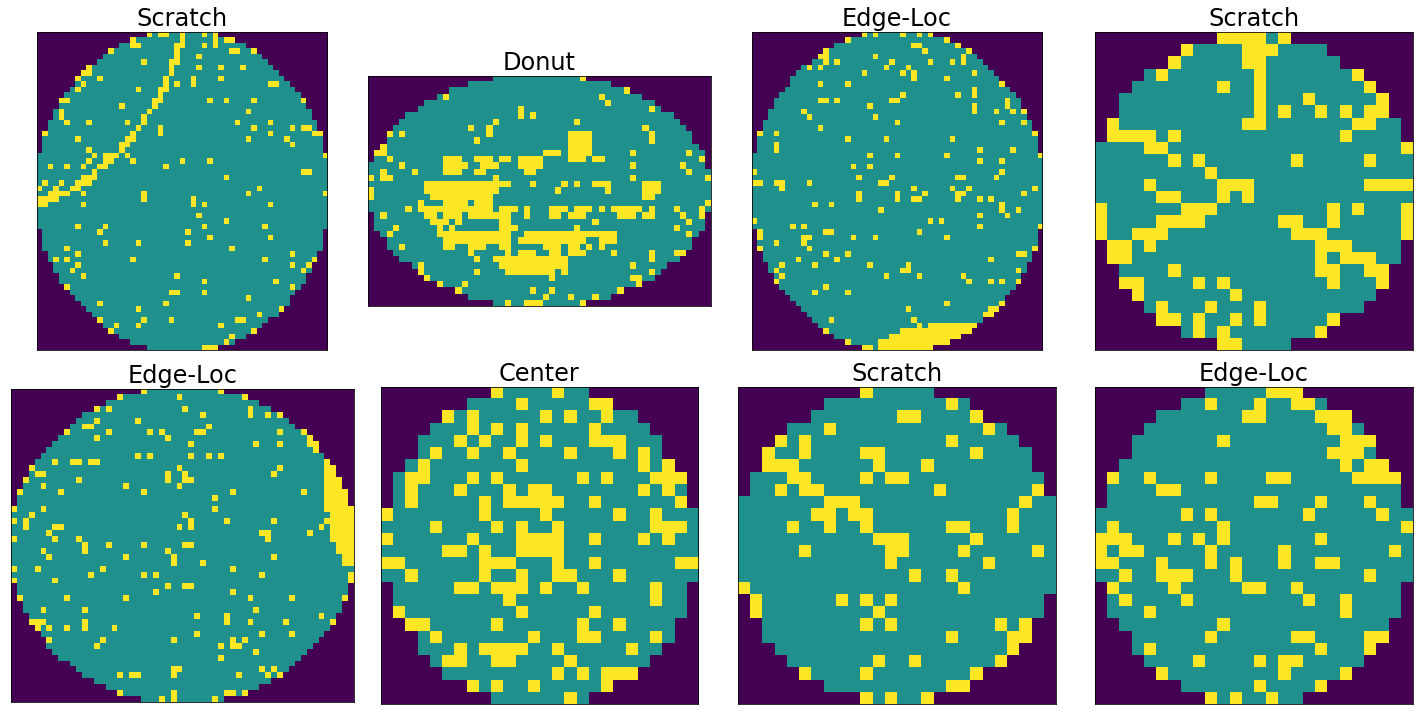

In [65]:
x = [9,340, 3, 16, 0, 25, 84, 37]
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

#ind_def = {'Center': 9, 'Donut': 340, 'Edge-Loc': 3, 'Edge-Ring': 16, 'Loc': 0, 'Random': 25,  'Scratch': 84, 'Near-full': 37}
fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    img = df_balanced.waferMap[x[i]]
    ax[i].imshow(img)
    ax[i].set_title(df_balanced.failureType[x[i]][0][0],fontsize=24)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.tight_layout()
plt.show() 

In [66]:
import skimage
from skimage import measure
from skimage.transform import radon
from skimage.transform import probabilistic_hough_line
from skimage import measure
from scipy import interpolate
from scipy import stats

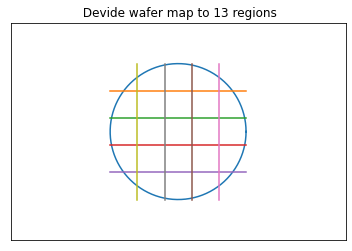

In [67]:
an = np.linspace(0, 2*np.pi, 100)
plt.plot(2.5*np.cos(an), 2.5*np.sin(an))
plt.axis('equal')
plt.axis([-4, 4, -4, 4])
plt.plot([-2.5, 2.5], [1.5, 1.5])
plt.plot([-2.5, 2.5], [0.5, 0.5 ])
plt.plot([-2.5, 2.5], [-0.5, -0.5 ])
plt.plot([-2.5, 2.5], [-1.5,-1.5 ])

plt.plot([0.5, 0.5], [-2.5, 2.5])
plt.plot([1.5, 1.5], [-2.5, 2.5])
plt.plot([-0.5, -0.5], [-2.5, 2.5])
plt.plot([-1.5, -1.5], [-2.5, 2.5])
plt.title(" Devide wafer map to 13 regions")
plt.xticks([])
plt.yticks([])
plt.show()

In [68]:
def cal_den(x):
    return 100*(np.sum(x==2)/np.size(x))  

def find_regions(x):
    rows=np.size(x,axis=0)
    cols=np.size(x,axis=1)
    ind1=np.arange(0,rows,rows//5)
    ind2=np.arange(0,cols,cols//5)
    
    reg1=x[ind1[0]:ind1[1],:]
    reg3=x[ind1[4]:,:]
    reg4=x[:,ind2[0]:ind2[1]]
    reg2=x[:,ind2[4]:]

    reg5=x[ind1[1]:ind1[2],ind2[1]:ind2[2]]
    reg6=x[ind1[1]:ind1[2],ind2[2]:ind2[3]]
    reg7=x[ind1[1]:ind1[2],ind2[3]:ind2[4]]
    reg8=x[ind1[2]:ind1[3],ind2[1]:ind2[2]]
    reg9=x[ind1[2]:ind1[3],ind2[2]:ind2[3]]
    reg10=x[ind1[2]:ind1[3],ind2[3]:ind2[4]]
    reg11=x[ind1[3]:ind1[4],ind2[1]:ind2[2]]
    reg12=x[ind1[3]:ind1[4],ind2[2]:ind2[3]]
    reg13=x[ind1[3]:ind1[4],ind2[3]:ind2[4]]
    
    fea_reg_den = []
    fea_reg_den = [cal_den(reg1),cal_den(reg2),cal_den(reg3),cal_den(reg4),cal_den(reg5),cal_den(reg6),cal_den(reg7),cal_den(reg8),cal_den(reg9),cal_den(reg10),cal_den(reg11),cal_den(reg12),cal_den(reg13)]
    return fea_reg_den

In [69]:
df_balanced['fea_reg']=df_balanced.waferMap.apply(find_regions)

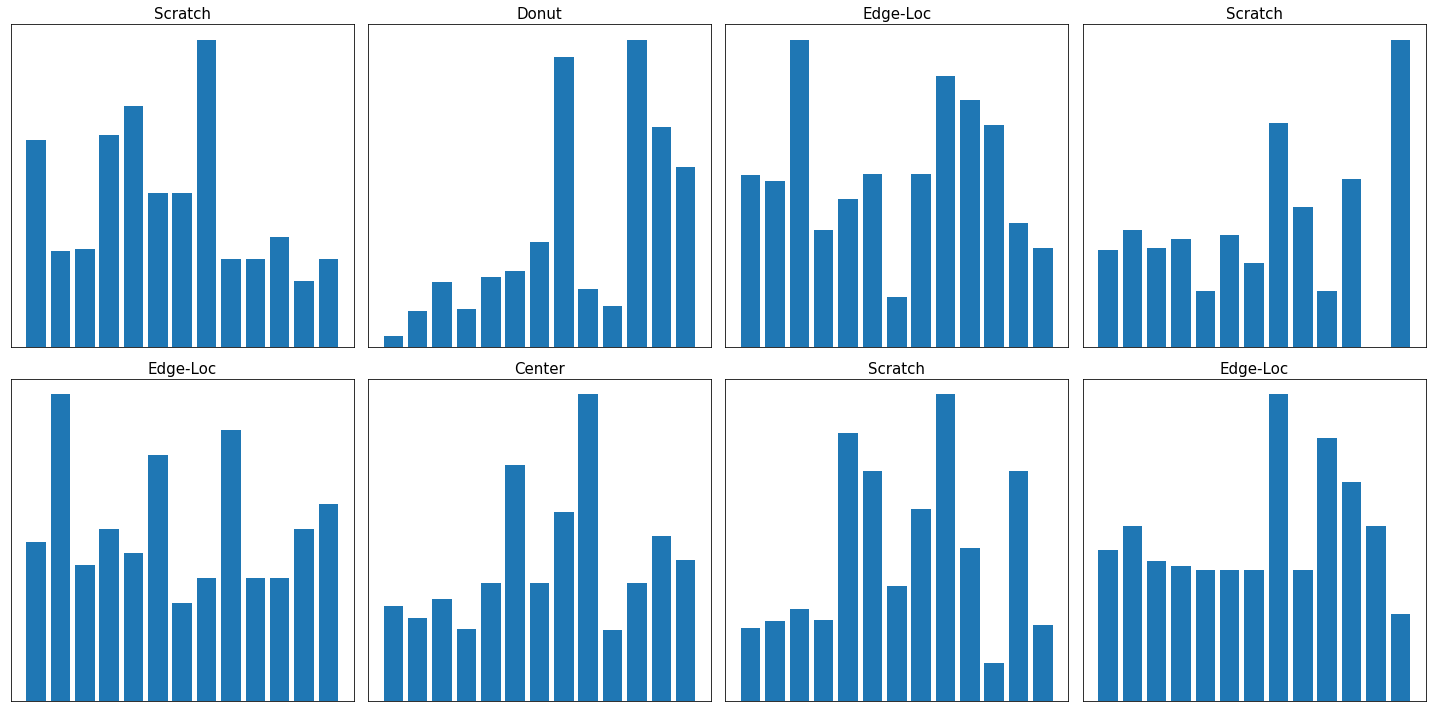

In [70]:
x = [9,340, 3, 16, 0, 25, 84, 37]
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

fig, ax = plt.subplots(nrows = 2, ncols = 4,figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    ax[i].bar(np.linspace(1,13,13),df_balanced.fea_reg[x[i]])
    ax[i].set_title(df_balanced.failureType[x[i]][0][0],fontsize=15)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.show() 

In [71]:
def change_val(img):
    img[img==1] =0  
    return img

df_balanced_copy = df_balanced.copy()
df_balanced_copy['new_waferMap'] =df_balanced_copy.waferMap.apply(change_val)

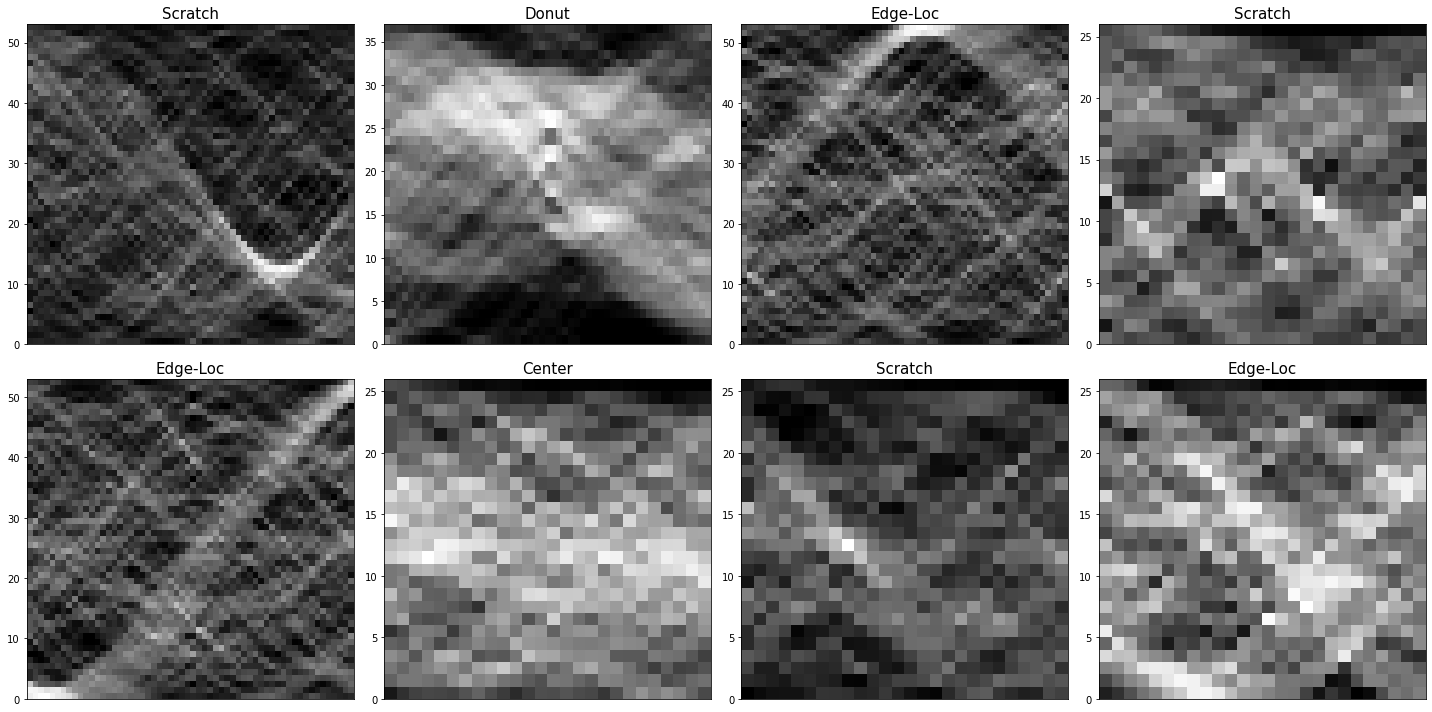

In [72]:
x = [9,340, 3, 16, 0, 25, 84, 37]
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    img = df_balanced_copy.waferMap[x[i]]
    theta = np.linspace(0., 180., max(img.shape), endpoint=False)
    sinogram = radon(img, theta=theta)    
      
    ax[i].imshow(sinogram, cmap=plt.cm.Greys_r, extent=(0, 180, 0, sinogram.shape[0]), aspect='auto')
    ax[i].set_title(df_balanced_copy.failureType[x[i]][0][0],fontsize=15)
    ax[i].set_xticks([])
plt.tight_layout()

plt.show() 

In [74]:
def cubic_inter_mean(img):
    theta = np.linspace(0., 180., max(img.shape), endpoint=False)
    sinogram = radon(img, theta=theta)
    xMean_Row = np.mean(sinogram, axis = 1)
    x = np.linspace(1, xMean_Row.size, xMean_Row.size)
    y = xMean_Row
    f = interpolate.interp1d(x, y, kind = 'cubic')
    xnew = np.linspace(1, xMean_Row.size, 20)
    ynew = f(xnew)/100   # use interpolation function returned by `interp1d`
    return ynew

def cubic_inter_std(img):
    theta = np.linspace(0., 180., max(img.shape), endpoint=False)
    sinogram = radon(img, theta=theta)
    xStd_Row = np.std(sinogram, axis=1)
    x = np.linspace(1, xStd_Row.size, xStd_Row.size)
    y = xStd_Row
    f = interpolate.interp1d(x, y, kind = 'cubic')
    xnew = np.linspace(1, xStd_Row.size, 20)
    ynew = f(xnew)/100   # use interpolation function returned by `interp1d`
    return ynew  

In [75]:
df_balanced_copy['fea_cub_mean'] = df_balanced_copy.waferMap.apply(cubic_inter_mean)
df_balanced_copy['fea_cub_std'] = df_balanced_copy.waferMap.apply(cubic_inter_std)

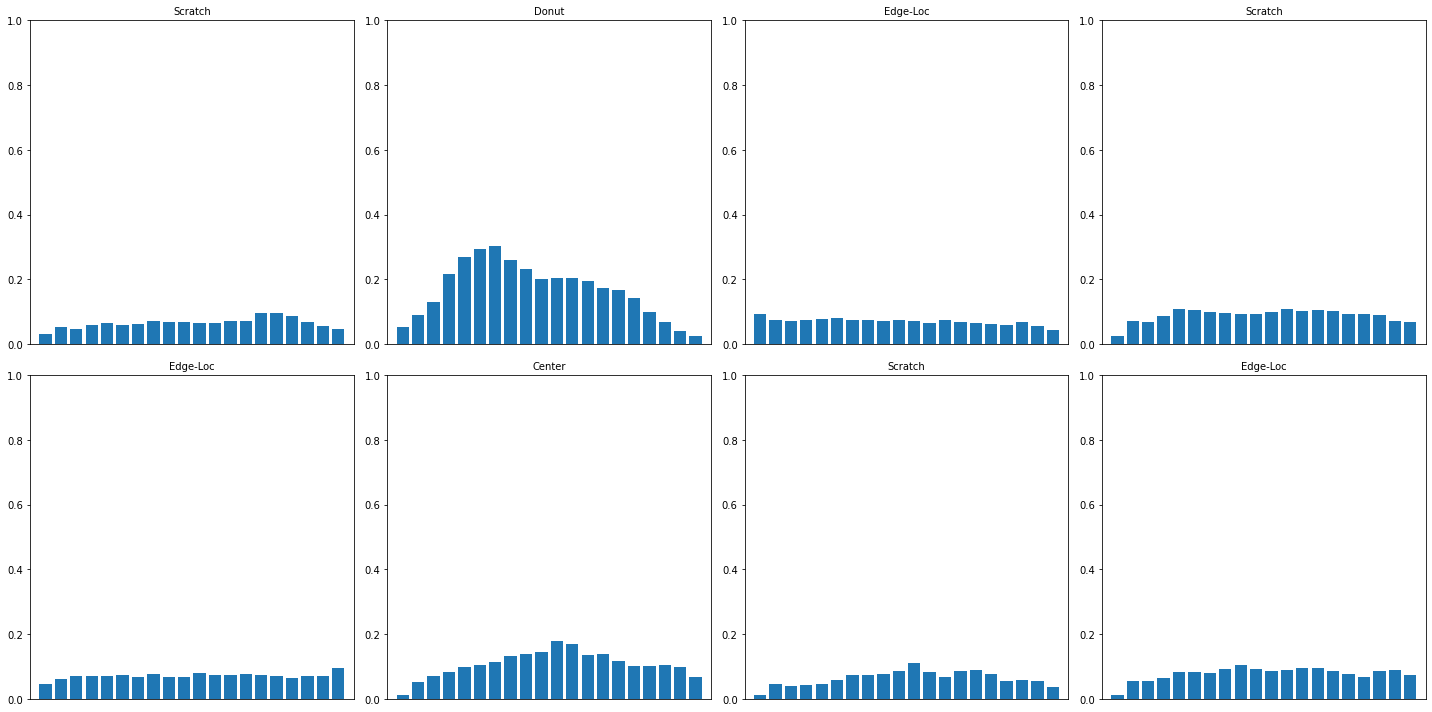

In [76]:
x = [9,340, 3, 16, 0, 25, 84, 37]
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

fig, ax = plt.subplots(nrows = 2, ncols = 4,figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    ax[i].bar(np.linspace(1,20,20),df_balanced_copy.fea_cub_mean[x[i]])
    ax[i].set_title(df_balanced_copy.failureType[x[i]][0][0],fontsize=10)
    ax[i].set_xticks([])
    ax[i].set_xlim([0,21])   
    ax[i].set_ylim([0,1])
plt.tight_layout()
plt.show() 

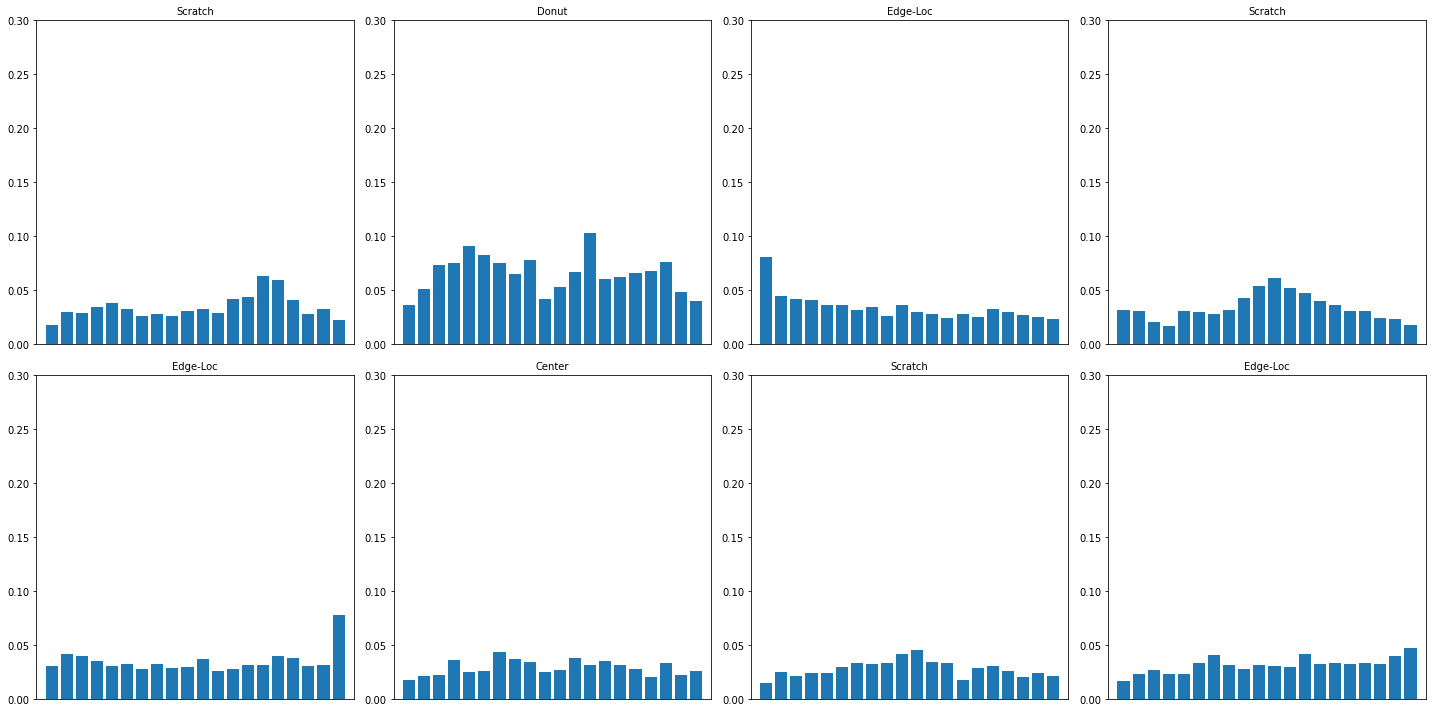

In [77]:
fig, ax = plt.subplots(nrows = 2, ncols = 4,figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    ax[i].bar(np.linspace(1,20,20),df_balanced_copy.fea_cub_std[x[i]])
    ax[i].set_title(df_balanced_copy.failureType[x[i]][0][0],fontsize=10)
    ax[i].set_xticks([])
    ax[i].set_xlim([0,21])   
    ax[i].set_ylim([0,0.3])
plt.tight_layout()
plt.show()

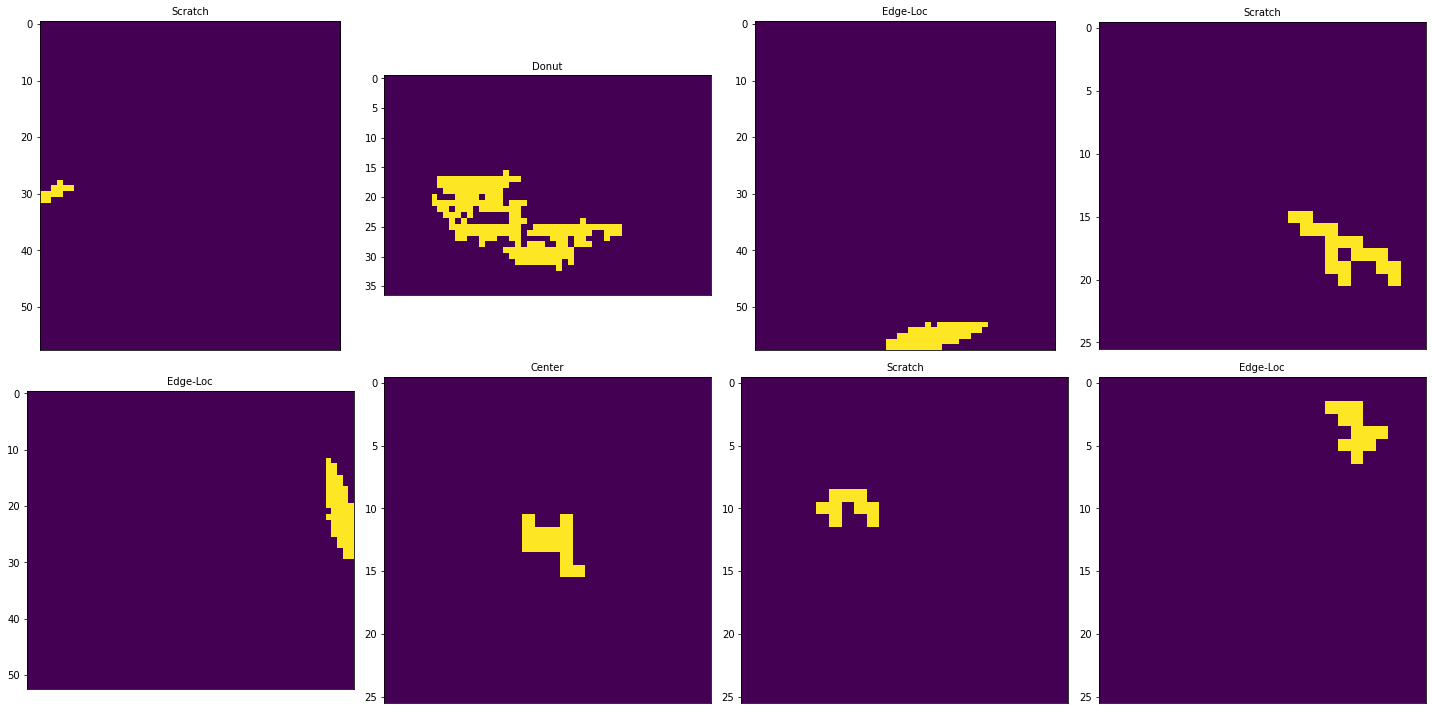

In [78]:
x = [9,340, 3, 16, 0, 25, 84, 37]
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

fig, ax = plt.subplots(nrows = 2, ncols = 4,figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    img = df_balanced_copy.waferMap[x[i]]
    zero_img = np.zeros(img.shape)
    img_labels = measure.label(img, neighbors=4, connectivity=1, background=0)
    img_labels = img_labels-1
    if img_labels.max()==0:
        no_region = 0
    else:
        info_region = stats.mode(img_labels[img_labels>-1], axis = None)
        no_region = info_region[0]
    
    zero_img[np.where(img_labels==no_region)] = 2 
    ax[i].imshow(zero_img)
    ax[i].set_title(df_balanced_copy.failureType[x[i]][0][0],fontsize=10)
    ax[i].set_xticks([])
plt.tight_layout()
plt.show() 

In [79]:
def cal_dist(img,x,y):
    dim0=np.size(img,axis=0)    
    dim1=np.size(img,axis=1)
    dist = np.sqrt((x-dim0/2)**2+(y-dim1/2)**2)
    return dist  

def fea_geom(img):
    norm_area=img.shape[0]*img.shape[1]
    norm_perimeter=np.sqrt((img.shape[0])**2+(img.shape[1])**2)
    
    img_labels = measure.label(img, neighbors=4, connectivity=1, background=0)

    if img_labels.max()==0:
        img_labels[img_labels==0]=1
        no_region = 0
    else:
        info_region = stats.mode(img_labels[img_labels>0], axis = None)
        no_region = info_region[0][0]-1       
    
    prop = measure.regionprops(img_labels)
    prop_area = prop[no_region].area/norm_area
    prop_perimeter = prop[no_region].perimeter/norm_perimeter 
    
    prop_cent = prop[no_region].local_centroid 
    prop_cent = cal_dist(img,prop_cent[0],prop_cent[1])
    
    prop_majaxis = prop[no_region].major_axis_length/norm_perimeter 
    prop_minaxis = prop[no_region].minor_axis_length/norm_perimeter  
    prop_ecc = prop[no_region].eccentricity  
    prop_solidity = prop[no_region].solidity  
    
    return prop_area,prop_perimeter,prop_majaxis,prop_minaxis,prop_ecc,prop_solidity

df_balanced_copy['fea_geom'] =df_balanced_copy.waferMap.apply(fea_geom)

In [80]:
df_balanced_copy.fea_geom[340] #donut

(0.09434889434889435,
 2.0341862568512155,
 0.4921400826731219,
 0.19350527335986809,
 0.9194566235595175,
 0.5614035087719298)

In [81]:
df_all=df_balanced_copy.copy()
a=[df_all.fea_reg[i] for i in range(df_all.shape[0])] #13
b=[df_all.fea_cub_mean[i] for i in range(df_all.shape[0])] #20
c=[df_all.fea_cub_std[i] for i in range(df_all.shape[0])] #20
d=[df_all.fea_geom[i] for i in range(df_all.shape[0])] #6
fea_all = np.concatenate((np.array(a),np.array(b),np.array(c),np.array(d)),axis=1) #59 in total

In [82]:
label=[df_all.failureNum[i] for i in range(df_all.shape[0])]
label=np.array(label)

In [83]:
import theano
from theano import tensor as T
from sklearn.model_selection import train_test_split
from keras.utils import np_utils

X = fea_all
y = label

from collections import  Counter
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)                      
print('Training target statistics: {}'.format(Counter(y_train)))
print('Testing target statistics: {}'.format(Counter(y_test)))

RANDOM_STATE =42

Training target statistics: Counter({0: 2404, 5: 2404, 2: 2400, 4: 2399, 3: 2381, 6: 2363, 1: 1697, 7: 464})
Testing target statistics: Counter({6: 837, 3: 819, 4: 801, 2: 800, 5: 796, 0: 796, 1: 523, 7: 132})


In [84]:
# One-Vs-One
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsOneClassifier
clf2 = OneVsOneClassifier(LinearSVC(random_state = RANDOM_STATE)).fit(X_train, y_train)
y_train_pred = clf2.predict(X_train)
y_test_pred = clf2.predict(X_test)
train_acc2 = np.sum(y_train == y_train_pred, axis=0, dtype='float') / X_train.shape[0]
test_acc2 = np.sum(y_test == y_test_pred, axis=0, dtype='float') / X_test.shape[0]
print('One-Vs-One Training acc: {}'.format(train_acc2*100)) #One-Vs-One Training acc: 80.36
print('One-Vs-One Testing acc: {}'.format(test_acc2*100)) #One-Vs-One Testing acc: 79.04
print("y_train_pred[:100]: ", y_train_pred[:100])
print ("y_train[:100]: ", y_train[:100])

One-Vs-One Training acc: 81.19549418604652
One-Vs-One Testing acc: 80.6686046511628
y_train_pred[:100]:  [0 6 0 5 2 6 5 5 2 6 2 6 6 1 4 3 4 5 2 4 1 2 4 2 2 6 2 3 2 3 6 2 3 2 0 2 4
 0 0 6 3 4 3 5 4 6 6 3 1 4 0 6 6 2 3 6 5 5 5 0 0 2 1 2 5 4 0 4 6 1 4 6 3 6
 5 1 1 2 2 5 1 5 4 6 3 2 1 5 5 6 6 0 1 3 3 3 3 3 1 1]
y_train[:100]:  [0 6 0 5 4 1 5 5 6 6 2 6 3 1 4 3 4 5 2 4 1 4 4 3 2 3 2 3 2 3 6 6 3 2 0 2 6
 0 0 6 3 4 3 7 4 6 6 3 1 5 0 6 6 4 3 6 7 2 5 0 0 2 1 2 5 6 0 4 1 1 4 4 3 6
 5 1 1 2 2 5 5 5 4 6 3 6 1 5 5 6 6 0 1 3 3 3 3 3 1 1]


In [85]:
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    #print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization
Normalized confusion matrix


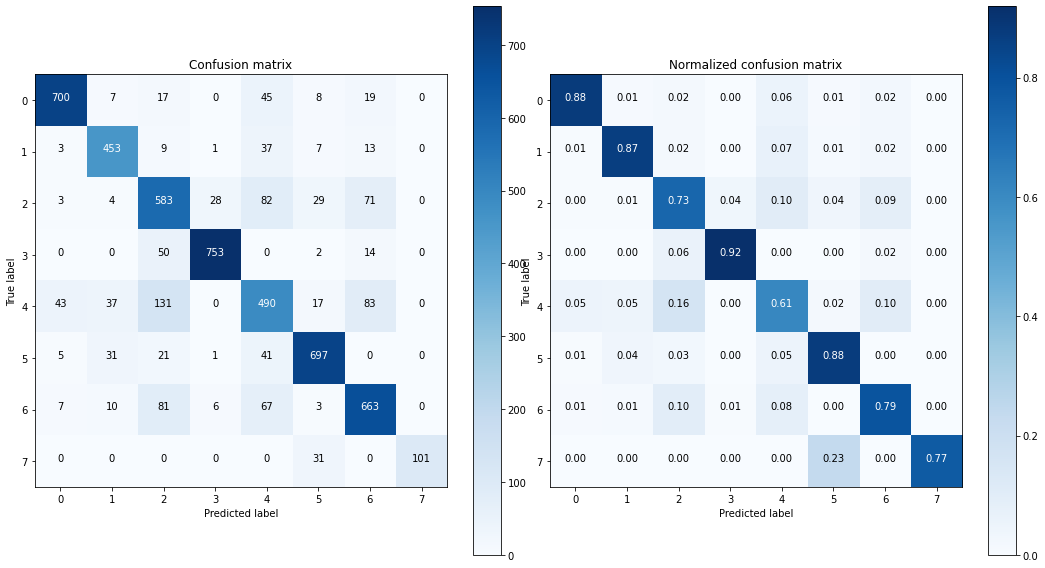

In [86]:
cnf_matrix = confusion_matrix(y_test, y_test_pred)
np.set_printoptions(precision=2)

from matplotlib import gridspec
fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1]) 

## Plot non-normalized confusion matrix
plt.subplot(gs[0])
plot_confusion_matrix(cnf_matrix, title='Confusion matrix')

# Plot normalized confusion matrix
plt.subplot(gs[1])
plot_confusion_matrix(cnf_matrix, normalize=True, title='Normalized confusion matrix')

plt.show()